In [50]:
import pandas as pd
import numpy as np
from pathlib import Path

import umap
import hdbscan
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import PCA
from clustering.hdbscan_optimize import optimize_umap_hdbscan_auto
from visualization.samples_plot import show_clustering_samples
from visualization.plot import plot_clustering_on_umap
from hdbscan.validity import validity_index


PROJECT_ROOT = Path.cwd().resolve().parent
EMBEDDING_DIR = PROJECT_ROOT / "data" / "glomeruli" / "embeddings"

EMBEDDING_NAME = "densenet_crops_embeddings"

embedding: np.ndarray = np.load(EMBEDDING_DIR / f"{EMBEDDING_NAME}.npy")
csv = pd.read_csv(EMBEDDING_DIR / f"{EMBEDDING_NAME}.csv")

n_samples = embedding.shape[0]

In [51]:
embedding_l2 = Normalizer(norm="l2").fit_transform(embedding)

pca_95 = PCA(n_components=0.95)
pca_95_embedding = pca_95.fit_transform(embedding_l2)

In [52]:
best = optimize_umap_hdbscan_auto(
    pca_95_embedding,
    n_runs=20,

    min_clusters=4,
    max_clusters=10,
    max_noise=0.25,

    min_valid_run_ratio=0.50,
    min_mean_ari=0.50,
    min_mean_dbcv=0.15,

    dbcv_weight=0.35,
    ari_weight=0.25,
    valid_run_ratio_weight=0.25,
    noise_weight=0.25,

    cluster_selection_method="leaf",
    max_auto_param_combinations=100,
)

best_params = best["best_params"]
best_n_components = best["best_n_components"]

if best_n_components is None:
    raise ValueError("No suitable number of components found for UMAP.")

print(best_params)

{'umap': {'n_neighbors': 34, 'min_dist': 0.05, 'metric': 'cosine', 'n_components': 40}, 'hdbscan': {'metric': 'euclidean', 'min_cluster_size': 51, 'min_samples': 26, 'cluster_selection_method': 'leaf'}, 'constraints': {'min_clusters': 3, 'max_clusters': 12, 'max_noise': 0.45, 'min_valid_run_ratio': 0.5, 'min_mean_ari': 0.5, 'min_mean_dbcv': 0.15}, 'selection': {'metric': 'combined_score', 'dbcv_weight': 0.3, 'ari_weight': 0.45, 'valid_run_ratio_weight': 0.25, 'noise_weight': 0.25, 'single_cluster_dbcv_for_score': 0.0}}


In [59]:
umap_params = best_params["umap"]

umap_embedding = umap.UMAP(
    n_neighbors=umap_params["n_neighbors"],
    min_dist=umap_params["min_dist"],
    n_components=umap_params["n_components"],
    metric=umap_params["metric"],
).fit_transform(pca_95_embedding)

In [60]:
hdbscan_params = best_params["hdbscan"]

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=hdbscan_params["min_cluster_size"],
    min_samples=hdbscan_params["min_samples"],
    metric=hdbscan_params["metric"],
    cluster_selection_method=hdbscan_params["cluster_selection_method"]
)

labels = clusterer.fit_predict(umap_embedding)

probabilities = clusterer.probabilities_    # How much a points belong to the assigned cluster
outlier_scores = clusterer.outlier_scores_  # How much a point is anomalous compared to the rest of the data

In [61]:
cluster_ids = sorted(label for label in np.unique(labels) if label != -1)

if len(cluster_ids) >= 2:
    dbcv_global, dbcv_per_cluster = validity_index(
        np.asarray(umap_embedding, dtype=np.float64),
        labels,
        metric="euclidean",
        per_cluster_scores=True,
    )
else:
    dbcv_global = np.nan
    dbcv_per_cluster = [np.nan for _ in cluster_ids]

dbcv_by_cluster = dict(zip(cluster_ids, dbcv_per_cluster))

cluster_dbcv_summary = pd.DataFrame(
    [
        {
            "cluster": int(cluster_id),
            "size": int(np.sum(labels == cluster_id)),
            "dbcv": float(dbcv_by_cluster[cluster_id]),
        }
        for cluster_id in cluster_ids
    ]
)

if np.any(labels == -1):
    cluster_dbcv_summary = pd.concat(
        [
            cluster_dbcv_summary,
            pd.DataFrame([
                {
                    "cluster": -1,
                    "size": int(np.sum(labels == -1)),
                    "dbcv": np.nan,
                }
            ]),
        ],
        ignore_index=True,
    )

print(f"DBCV globale: {dbcv_global:.4f}")
display(cluster_dbcv_summary.sort_values("cluster").reset_index(drop=True))

DBCV globale: 0.4561


,cluster,size,dbcv
0,-1,269,NaN
1,0,223,0.841462
2,1,114,0.677995
3,2,71,0.617380


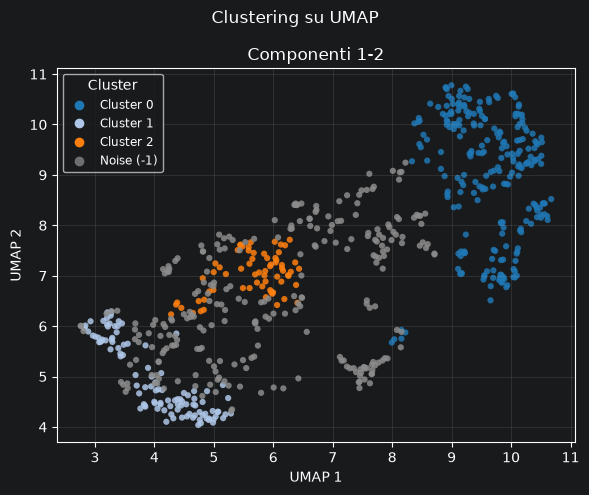

(<Figure size 600x500 with 1 Axes>,
 (<Axes: title={'center': 'Componenti 1-2'}, xlabel='UMAP 1', ylabel='UMAP 2'>,))

In [56]:
plot_clustering_on_umap(
    pca_95_embedding,
    labels,
    min_dist=0.05,
    n_neighbors=umap_params["n_neighbors"],
)

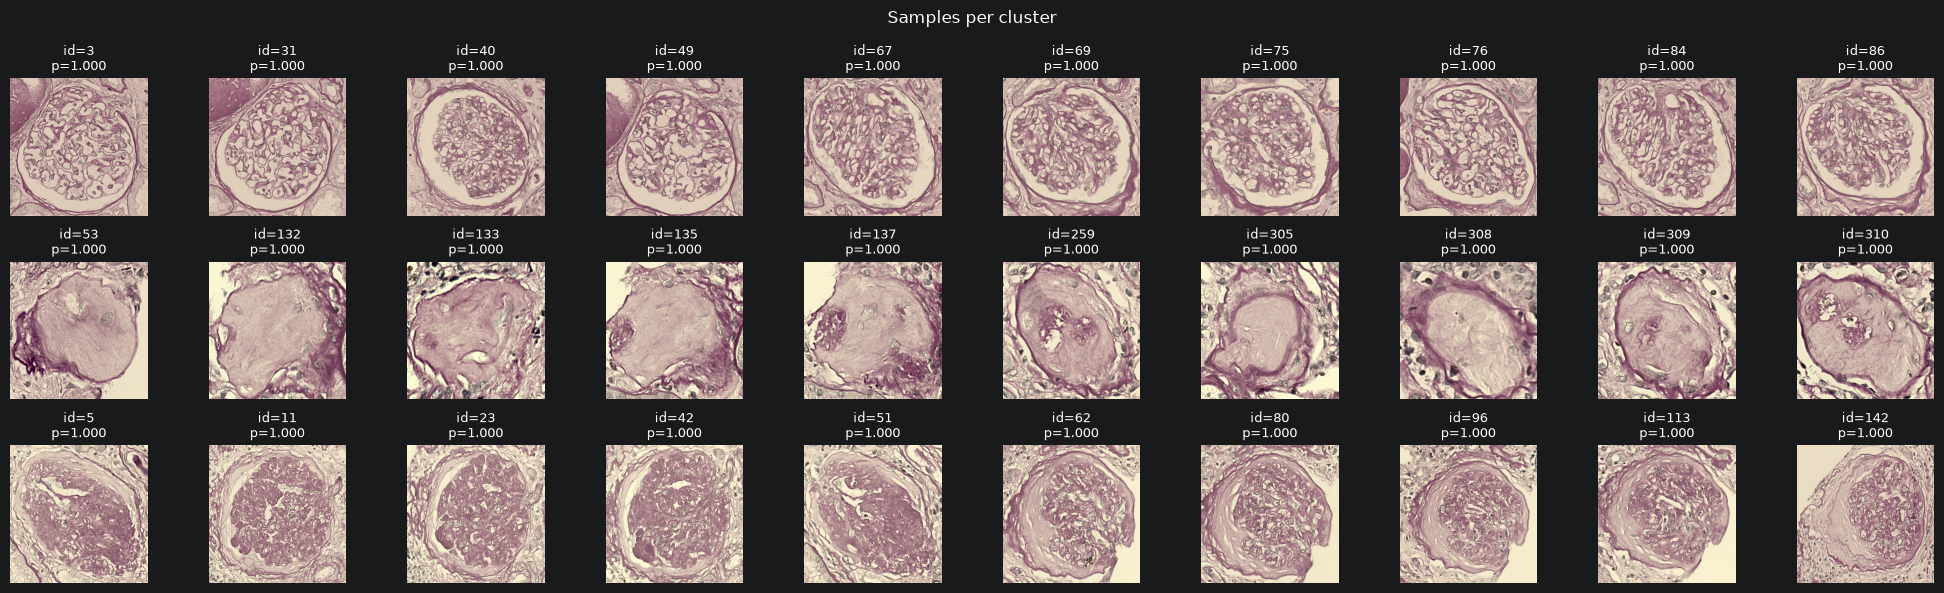

In [57]:
image_paths = csv["image_path"].tolist()

sample_figure, sample_axes = show_clustering_samples(
    labels=labels,
    probabilities=clusterer.probabilities_,
    image_paths=image_paths,
    x=10,
    base_dir=PROJECT_ROOT,
    image_size=2.0,
)

In [58]:
cols = [
    "n_components",
    "successful_runs",
    "valid_runs",
    "valid_run_ratio",
    "mean_dbcv",
    "mean_ari",
    "mean_dbcv_all",
    "mean_ari_all",
    "mean_n_clusters_all",
    "mean_noise_ratio_all",
    "valid_for_selection",
]

print(best["results"][cols].sort_values("n_components"))

print(
    best["run_details"]
    .groupby(["n_components", "constraint_reason"])
    .size()
    .unstack(fill_value=0)
)

    n_components  successful_runs  valid_runs  valid_run_ratio  mean_dbcv  \
5             10               20          19             0.95   0.284678   
14            10               20          16             0.80   0.271076   
13            10               20          20             1.00   0.203905   
18            10               20          19             0.95   0.210999   
22            10               20          16             0.80   0.245076   
..           ...              ...         ...              ...        ...   
86            50               20           3             0.15   0.187018   
93            50               20           2             0.10   0.190138   
82            50               20           5             0.25   0.227780   
83            50               20           2             0.10   0.358081   
99            50               20           0             0.00        NaN   

    mean_ari  mean_dbcv_all  mean_ari_all  mean_n_clusters_all  \
5   0.669